# Electrostatic Potential of a Peptide from MBIS Atomic Multipoles

This notebook demonstrates the FFprime multipole electrostatics workflow on a peptide structure: computing MBIS atomic multipoles, constructing a multipole expansion, and visualizing the resulting electrostatic potential.

## Imports

In [9]:
import sys
from pathlib import Path

# Allow importing the local ffprime package when running this notebook
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from ffprime.nb import Nonbonded
from ffprime.electrostatics.cartesian import total_potential


## Load Molecule

Load the peptide structure and compute MBIS atomic multipoles.

In [2]:
nb = Nonbonded.from_file(
    "peptide.fchk",
    schemes=["mbis"],
    args="fine",
)


LOAD peptide.fchk, LOT=None
PREPARE molecule (12 atoms)


c:\Users\ranja\miniconda3\envs\env_qcdevs\lib\site-packages\grid\atomgrid.py:895: UserWarning: Lebedev weights are negative which can introduce round-off errors.
  sphere_grid = AngularGrid(degree=deg_i, method=method)


PART MBIS ...
Building local grids
Integral of density: 40.000304584947834
Optimization
#Iter  #Call         ekld          kld  -constraint     grad.rms  cputime (s)
-----  -----  -----------  -----------  -----------  -----------  -----------
    1      1    1.3144532    1.3147578  -3.0458e-04   1.9792e-01    0.0781250
    2      2    0.8137006    0.3658150   4.4789e-01   1.0297e-01    0.0312500
    3      3    0.8825129   -0.8967302   1.7792e+00   2.2966e-01    0.0312500
    4      4    0.5797553   -1.1129467   1.6927e+00   7.7750e-02    0.0312500
    5      5    0.5582083   -1.0703005   1.6285e+00   6.7729e-02    0.0312500
    6      5    0.5582083   -1.0703005   1.6285e+00   6.7729e-02    0.0312500
    7      6    0.4553857   -0.3123853   7.6777e-01   3.8603e-02    0.0312500
    8      7    0.4117605    0.4112758   4.8469e-04   1.4730e-02    0.0468750
    9      8    0.4102579    0.3659374   4.4320e-02   1.5453e-02    0.0468750
   10      9    0.4029096    0.3384188   6.4491e-02   

## Sanity Checks

In [3]:
print("=" * 40)
print("MBIS Multipole Summary")
print("=" * 40)
print(f"Atoms         : {len(nb.atcoords)}")
print(f"Coordinates   : {nb.atcoords.shape}")
print(f"Charges       : {nb.atcharges.shape}")
print(f"Dipoles       : {nb.atdipoles.shape}")
print(f"Quadrupoles   : {nb.atquadrupoles.shape}")
print(f"Total charge  : {np.sum(nb.atcharges):.6f}")


MBIS Multipole Summary
Atoms         : 12
Coordinates   : (12, 3)
Charges       : (12,)
Dipoles       : (12, 3)
Quadrupoles   : (12, 6)
Total charge  : -0.000305


## Convert Flattened Quadrupoles to Tensor Form

In [4]:
def quadrupoles_flat_to_tensor(flat):
    """
    Convert flattened Cartesian quadrupoles

        (xx, xy, xz, yy, yz, zz)

    into full symmetric 3x3 tensors.
    """
    flat = np.asarray(flat)
    tensor = np.zeros((flat.shape[0], 3, 3))

    # Diagonal terms
    tensor[:, 0, 0] = flat[:, 0]  # xx
    tensor[:, 1, 1] = flat[:, 3]  # yy
    tensor[:, 2, 2] = flat[:, 5]  # zz

    # Off-diagonal terms
    tensor[:, 0, 1] = tensor[:, 1, 0] = flat[:, 1]  # xy
    tensor[:, 0, 2] = tensor[:, 2, 0] = flat[:, 2]  # xz
    tensor[:, 1, 2] = tensor[:, 2, 1] = flat[:, 4]  # yz

    return tensor


quad_tensor = quadrupoles_flat_to_tensor(nb.atquadrupoles)
print(quad_tensor.shape)


(12, 3, 3)


## Compute Electrostatic Potential

Build an evaluation grid in the XY plane, automatically sized to the molecule, and evaluate the monopole-only and full multipole potentials on it.

In [5]:
# Automatically determine plotting region from the molecule's extent
margin = 2.0

xmin = nb.atcoords[:, 0].min() - margin
xmax = nb.atcoords[:, 0].max() + margin

ymin = nb.atcoords[:, 1].min() - margin
ymax = nb.atcoords[:, 1].max() + margin

x = np.linspace(xmin, xmax, 300)
y = np.linspace(ymin, ymax, 300)

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

points = np.column_stack([
    X.ravel(),
    Y.ravel(),
    Z.ravel(),
])


In [6]:
V_mono = total_potential(
    atcoords=nb.atcoords,
    points=points,
    atcharges=nb.atcharges,
)

V_full = total_potential(
    atcoords=nb.atcoords,
    points=points,
    atcharges=nb.atcharges,
    dipoles=nb.atdipoles,
    quadrupoles=quad_tensor,
)

V_diff = V_full - V_mono


## Reshape to Grid

In [7]:
V_mono = V_mono.reshape(X.shape)
V_full = V_full.reshape(X.shape)
V_diff = V_diff.reshape(X.shape)


## Visualize Results

The figure compares the electrostatic potential obtained from a monopole-only approximation with the full MBIS multipole expansion (monopole + dipole + quadrupole). The third panel highlights the contribution of higher-order multipoles.

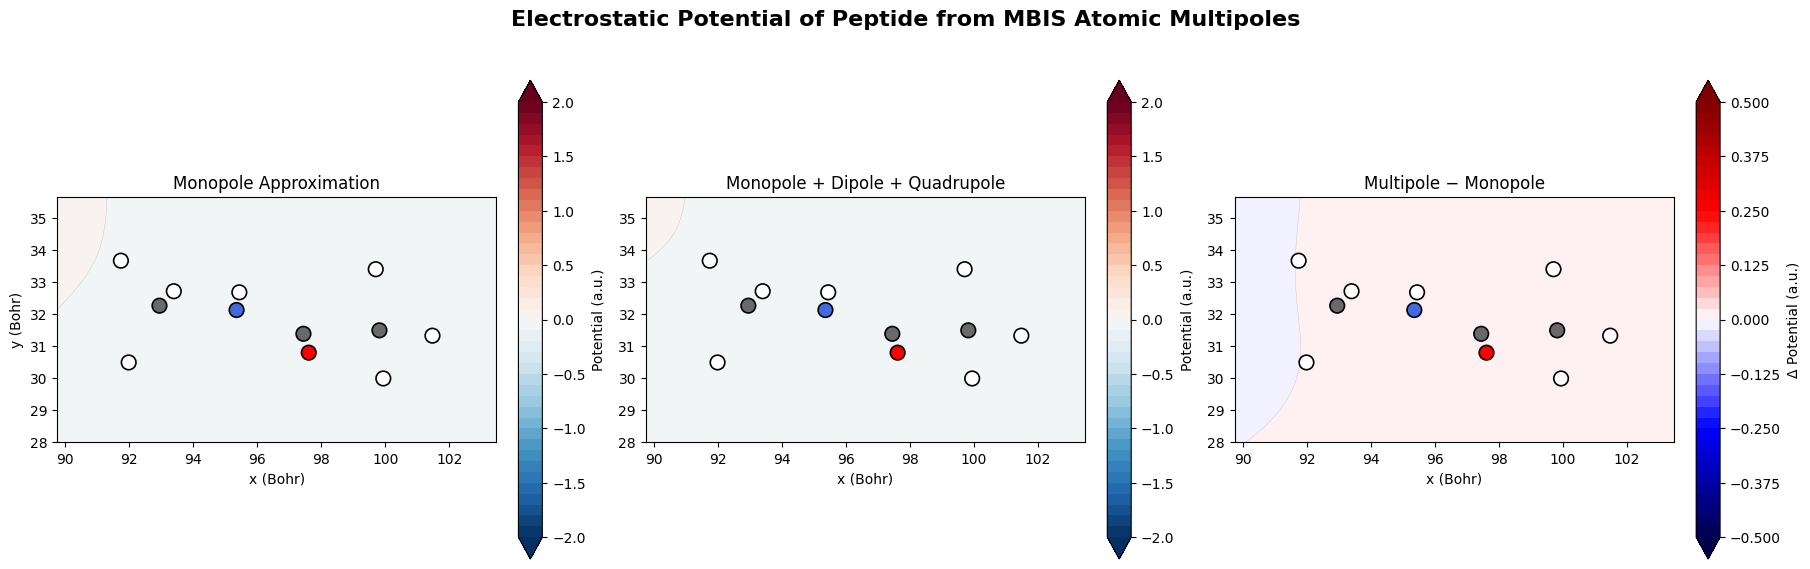

In [8]:
# Clip values for visualization
mono_clip = 2.0
full_clip = 2.0
diff_clip = 0.5

Vmono_plot = np.clip(V_mono, -mono_clip, mono_clip)
Vfull_plot = np.clip(V_full, -full_clip, full_clip)
Vdiff_plot = np.clip(V_diff, -diff_clip, diff_clip)

# Element-based atom coloring (fallback to gray for unlisted elements)
element_colors = {
    1: "white",      # H
    6: "dimgray",    # C
    7: "royalblue",  # N
    8: "red",        # O
}
colors = [element_colors.get(Z, "gray") for Z in nb.atnums]
edgecolors = ["black"] * len(nb.atnums)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

fig.suptitle(
    "Electrostatic Potential of Peptide from MBIS Atomic Multipoles",
    fontsize=16,
    fontweight="bold",
)

# Shared color limits for the first two panels; separate diverging scale for the difference
levels = np.linspace(-mono_clip, mono_clip, 41)
diff_levels = np.linspace(-diff_clip, diff_clip, 41)

# --- Monopole approximation ---
cf1 = axes[0].contourf(X, Y, Vmono_plot, levels=levels, cmap="RdBu_r", extend="both")
axes[0].contour(X, Y, Vmono_plot, levels=levels, colors="k", linewidths=0.2, alpha=0.3)
axes[0].scatter(
    nb.atcoords[:, 0], nb.atcoords[:, 1],
    c=colors, edgecolors=edgecolors, s=110, linewidths=1.2, zorder=10,
)
axes[0].set_title("Monopole Approximation")
axes[0].set_xlabel("x (Bohr)")
axes[0].set_ylabel("y (Bohr)")
axes[0].set_aspect("equal")
plt.colorbar(cf1, ax=axes[0], shrink=0.85, label="Potential (a.u.)")

# --- Full multipole expansion ---
cf2 = axes[1].contourf(X, Y, Vfull_plot, levels=levels, cmap="RdBu_r", extend="both")
axes[1].contour(X, Y, Vfull_plot, levels=levels, colors="k", linewidths=0.2, alpha=0.3)
axes[1].scatter(
    nb.atcoords[:, 0], nb.atcoords[:, 1],
    c=colors, edgecolors=edgecolors, s=110, linewidths=1.2, zorder=10,
)
axes[1].set_title("Monopole + Dipole + Quadrupole")
axes[1].set_xlabel("x (Bohr)")
axes[1].set_aspect("equal")
plt.colorbar(cf2, ax=axes[1], shrink=0.85, label="Potential (a.u.)")

# --- Difference ---
cf3 = axes[2].contourf(X, Y, Vdiff_plot, levels=diff_levels, cmap="seismic", extend="both")
axes[2].contour(X, Y, Vdiff_plot, levels=diff_levels, colors="k", linewidths=0.2, alpha=0.3)
axes[2].scatter(
    nb.atcoords[:, 0], nb.atcoords[:, 1],
    c=colors, edgecolors=edgecolors, s=110, linewidths=1.2, zorder=10,
)
axes[2].set_title("Multipole \u2212 Monopole")
axes[2].set_xlabel("x (Bohr)")
axes[2].set_aspect("equal")
plt.colorbar(cf3, ax=axes[2], shrink=0.85, label="\u0394 Potential (a.u.)")

for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(False)

plt.savefig("peptide_multipole_potential.png", dpi=300, bbox_inches="tight")
plt.show()
